## 📊 Logistic Regression 

### Sample data Preparation
---

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("usa_houses.csv", header=0)
df = df[(df["price"] > 10000) & (df["price"] < 2000000)]
df = df[["price" ,"sqft_living", "bathrooms", "bedrooms", "floors", "view"]]
df["price"] = np.where(df["price"] < 500000, "high", "low")
df.head()

,price,sqft_living,bathrooms,bedrooms,floors,view
0,high,1340,2.00,3.0,3.0,0
1,low,3540,3.25,4.0,2.0,0
3,high,998,2.25,3.0,2.0,0
4,low,3060,2.75,5.0,1.0,0
5,high,2130,2.50,3.0,2.0,0


---

## 📊 Logistic Regression 

### -What is Logistic Regression? 🤔
Logistic regression is a **classification algorithm** used to predict **discrete outcomes** (categories) rather than continuous values.  
Examples of discrete outcomes:
- 📧 Email is *spam* or *not spam*
- 🩺 Tumor is *benign* or *malignant*
- 🌦 Weather is *rainy* or *sunny*

Instead of predicting a numeric value directly, logistic regression estimates the **probability** that an input belongs to a given class.

### - Advantages 🌟
- 📏 Simple and interpretable  
- 📈 Outputs calibrated probabilities  
- 🏆 Works well for linearly separable data  
- 🔄 Can be extended to multiclass problems (One-vs-Rest or multinomial)
- 📏 Supports Regolarization


### - Limitations ⚠️
- 📉 Assumes a linear relationship between features and log-odds  
- 🌀 Struggles with complex, nonlinear boundaries unless features are transformed  
- 🔍 Sensitive to multicollinearity between features

### 🧩 Types of Logistic Regression
- **Binary Logistic Regression**: predicts between two classes (e.g., spam vs. not spam), uses sigmoid functon.  
- **Multiclass Logistic Regression**: extended using:
  - 🔄 *One-vs-Rest (OvR)* strategy  
  - 🔄 *Multinomial (softmax)* strategy  

# Bynary Classification Example : 

#### Splitting Features and Target : 

In [6]:
binary_features = df[["sqft_living", "bathrooms", "bedrooms", "floors", "view"]]
binary_target = df["price"]
print(binary_target.value_counts())

price
high    2272
low     1773
Name: count, dtype: int64


### Scaling 

In [7]:
from sklearn.preprocessing import StandardScaler
scaled_features = StandardScaler().fit_transform(binary_features)

### Training The LOgistic Regression 

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_regr_model = LogisticRegression(solver = 'liblinear', class_weight= 'balanced', C=1)
logistic_regr_model.fit(scaled_features, binary_target)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


### Getting a prediction and an accuracy score from the model

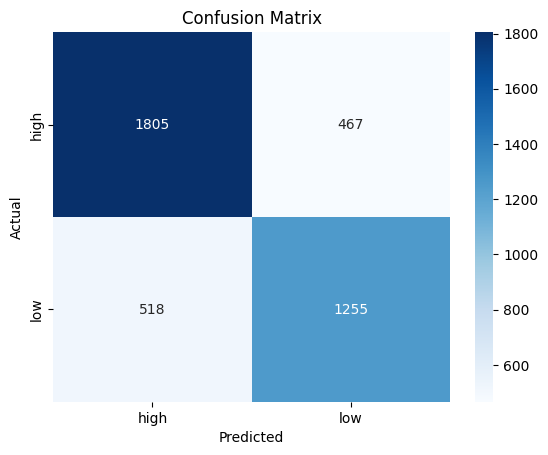

Confusion Matrix:
 [[1805  467]
 [ 518 1255]]


In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions & evaluation
y_pred = logistic_regr_model.predict(scaled_features)

confusion_matrix = confusion_matrix(binary_target, y_pred)
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=logistic_regr_model.classes_, yticklabels=logistic_regr_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Confusion Matrix:\n", confusion_matrix)

###  Evaluating the Logistic Regression Model 

### **Accuracy Score**

-  Accuracy = (Number of correct predictions) / (Total number of predictions)

Accuracy is good to have a general idea of how good is the model performing overall but can be sometimes misleading in imbalanced datasets,  
for example if 80 % of patients are healthy and the model predicts that all → use Precision, Recall, F1, or ROC-AUC as complementary metrics.

### **Precision Score**

- Precision = (True Positives) / (True Positives + False Positives)

Precision answers the question: *“Of all the instances the model predicted as positive, how many were actually positive?”*  

This metric is especially useful when the **cost of false positives is high**.  
For example, in a medical diagnosis scenario, if the model predicts that a patient has a disease, precision tells us how often that prediction is correct.  

- High Precision → Few false alarms (the model rarely mislabels negatives as positives).  
- Low Precision → Many false alarms (the model often mislabels negatives as positives).  

Precision alone does not capture how many actual positives the model missed (that’s Recall’s job).  
That’s why it is often reported together with **Recall** and summarized in the **F1-score**.

### **Recall Score**

- Recall = (True Positives) / (True Positives + False Negatives)

Recall answers the question: *“Of all the actual positive cases, how many did the model correctly identify?”*  

This metric is especially important when **missing a positive case is costly**.  
For example, in medical screening, recall tells us how many sick patients were correctly flagged by the model.  

- High Recall → The model catches most of the actual positives (few missed cases).  
- Low Recall → The model misses many actual positives (many false negatives).  

A model with very high recall may still have low precision if it also produces many false alarms. That’s why recall is often evaluated together with precision.

### **F1-Score**

- F1 = 2 × (Precision × Recall) / (Precision + Recall)

The F1-score is the **harmonic mean** of precision and recall.  
It provides a single metric that balances both, especially useful when the dataset is **imbalanced** or when both false positives and false negatives matter.  

- High F1 → The model achieves a good balance between precision and recall.  
- Low F1 → The model struggles with either precision, recall, or both.  

The harmonic mean is chosen because it penalizes extreme differences:  
if precision is high but recall is very low (or vice versa), the F1-score will also be low.

### Specificity

- **Specificity** = TrueNegative / (TrueNegative + FalsePositive)  ** From confusion Matrix
- Measures how well the model avoids false positives.

Specificity measures how well the model correctly identifies **negatives**.  
It answers the question: *“Of all the actual negatives, how many did the model correctly classify as negative?”*


### 📌 Summary of Classification Metrics

- **Accuracy** → Measures overall correctness: the proportion of all predictions that were correct.  
- **Precision** → Focuses on predicted positives: how many were actually correct.  
- **Recall (Sensitivity)** → Focuses on actual positives: how many were successfully identified.  
- **F1-score** → Harmonic mean of precision and recall: balances false positives and false negatives.  
- **Specificity (True Negative Rate)** → Focuses on actual negatives: how many were correctly rejected (avoiding false alarms).


In [10]:
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score 
print("Accuracy:", accuracy_score(binary_target, y_pred))
print("Precision:", precision_score(binary_target, y_pred, pos_label="high"))
print("Recall:", recall_score(binary_target, y_pred, pos_label="high"))
print("F1 Score:", f1_score(binary_target, y_pred, pos_label="high"))
print("Specificity:", confusion_matrix[1,1] / (confusion_matrix[1,0] + confusion_matrix[1,1]))


Accuracy: 0.7564894932014833
Precision: 0.7770124838570813
Recall: 0.7944542253521126
F1 Score: 0.7856365614798694
Specificity: 0.7078398195149465


# Classification Report 

Classification report is a fast function to access classification metrics in a fast way

In [11]:
from sklearn.metrics import classification_report 

class_report = classification_report(binary_target, y_pred)
print("\nClassification Report:\n", class_report)
print(type(class_report))


Classification Report:
               precision    recall  f1-score   support

        high       0.78      0.79      0.79      2272
         low       0.73      0.71      0.72      1773

    accuracy                           0.76      4045
   macro avg       0.75      0.75      0.75      4045
weighted avg       0.76      0.76      0.76      4045

<class 'str'>


### Trade off between Precision and Recall 

Often Precision and recall are in conflict, let's imagine classifying spam emails:   

- If we lower the decision boundary more emails will be classifyed as spam, recall gets better (almost all spam mail go in the)wbut precision get worse(more legit mail get in the spam folder)

- If we Increase decision boundary less emails will be classified as spam precision gets better(more legit emails are well classified) and recall get worse (more spam mails gets classified as legit)

## Precision–Recall Curve

- **Axes**:
  - X-axis: **Recall (Sensitivity)** = TP / (TP + FN)
  - Y-axis: **Precision (Positive Predictive Value)** = TP / (TP + FP)

- **How to read**:
  - The curve shows the trade-off between **catching more positives (Recall)** and **being correct when predicting positive (Precision)**.
  - The **baseline** is the prevalence of positives in the dataset (random classifier).
  - A good model’s curve stays **high and to the right** (high Precision at high Recall).

- **Interpretation**:
  - PR curves are especially informative for **imbalanced datasets** (rare positives).
  - They answer: *“When the model predicts positive, how much can I trust it — and how many positives do I actually find?”*

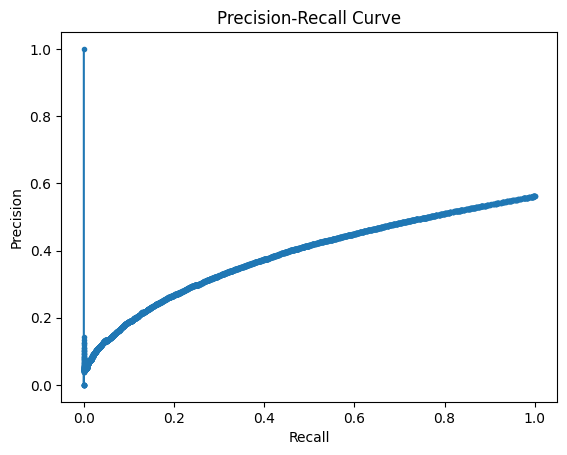

AUC-PR: 0.38664962264372515


In [12]:
from sklearn.metrics import precision_recall_curve , auc 

y_scores = logistic_regr_model.predict_proba(scaled_features)[:, 1]
precision , recall , thresholds = precision_recall_curve(binary_target , y_scores, pos_label="high")

pr_auc = auc(recall , precision)
plt.plot(recall , precision , marker=".")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()
print("AUC-PR:", pr_auc)

## ROC Curve (Receiver Operating Characteristic)

- **Axes**:
  - X-axis: **False Positive Rate (FPR)** = FP / (FP + TN)
  - Y-axis: **True Positive Rate (TPR, Recall)** = TP / (TP + FN)

- **How to read**:
  - The diagonal line (from (0,0) to (1,1)) represents **random guessing**.
  - A good model’s curve bows **towards the top-left corner** (high TPR, low FPR).
  - The **Area Under the Curve (AUC)** summarizes performance:
    - AUC = 0.5 → random
    - AUC = 1.0 → perfect classifier

- **Interpretation**:
  - ROC is useful when classes are **balanced** or when both false positives and false negatives are equally important.
  - It answers: *“How well can the model separate positives from negatives overall?”*

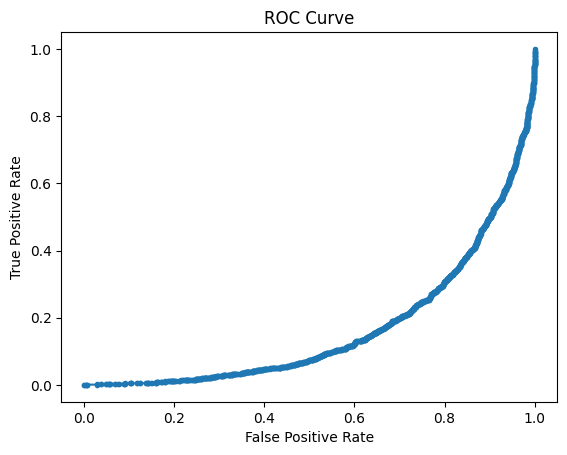

In [13]:
from sklearn.metrics import roc_curve , roc_auc_score

fpr , tpr , thresholds = roc_curve(binary_target , y_scores, pos_label="high")
roc_auc = roc_auc_score(binary_target , y_scores)
plt.plot(fpr , tpr , marker=".")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


### ⚠️ The Problem of Class Imbalance and Its Possible Solutions

In many real-world classification tasks, the target classes are **not equally represented**. This is known as **class imbalance**, and it can severely affect model performance.

#### 🔍 Examples of Imbalanced Scenarios:
- **Fraud detection**: Only ~1 in 100 transactions may be fraudulent.
- **Rare disease diagnosis**: 1 in 1000 patients may have a specific genetic condition.
- **Industrial failure prediction**: Machine breakdowns are rare compared to normal operation.


### ❌ Issues It Creates:

- **Misleading Accuracy**: A model that always predicts the majority class can achieve high accuracy, but it’s useless for detecting the minority class.
- **Poor Minority Detection**: The model may ignore the minority class entirely, as its contribution to the loss function is minimal.
- **Bias Toward Majority**: Standard algorithms tend to favor the dominant class unless explicitly corrected.


### ✅ How We Can Manage It:

#### 🔁 Resampling Techniques
- **Undersampling**: Reduce the number of majority class samples to balance the dataset.
- **Oversampling**: Duplicate or synthetically generate minority class samples to increase their representation.

#### 🧪 SMOTE (Synthetic Minority Over-sampling Technique)
- Creates **synthetic examples** of the minority class by interpolating between existing samples.
- Helps avoid overfitting that can occur with naive oversampling.

#### ⚖️ Class Weighting
- Assign **higher weights** to the minority class during training.
- Forces the algorithm to pay more attention to underrepresented classes.
- Most scikit-learn classifiers support `class_weight='balanced'`.

#### 📊 Metric Selection
Use metrics that reflect minority class performance like **Precision**, **Recall**, **F1-score**

### Undersampling The Bigger Class :

In [14]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(scaled_features, binary_target)
print(y_resampled.value_counts())

price
high    1773
low     1773
Name: count, dtype: int64


### Oversampling The underdog class

In [15]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(scaled_features, binary_target)
print(y_resampled.value_counts())

price
high    2272
low     2272
Name: count, dtype: int64


# Sytetic Underdog Class Population

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(scaled_features, binary_target)
print(y_resampled.value_counts())

price
high    2272
low     2272
Name: count, dtype: int64


### Class Weighting

Class weighting adjusts the loss function to give more importance to underrepresented classes.

- balanced → weights are computed automatically based on class frequencies.
- Manual weights → you can assign custom importance to each class.

#### **Example of weighting implementation :**
```python
model = LogisticRegression(class_weight='balanced') # model = LogisticRegression(class_weight={0: 1.0, 1: 3.0})
```

### Multiclass Classification

Binary classification can be generalized to multiclass problems through three main strategies: One-vs-Rest (OvR), where each class is compared against all others; One-vs-One (OvO), where classifiers are trained for every pair of classes; and the multinomial (softmax) formulation, which directly models all classes simultaneously.

### Data Loading Iris Dataset :

In [17]:
df_2 = pd.read_csv("iris.csv", header=0)

# Use the actual column names from your CSV
df_2 = df_2[["sepal.length", "sepal.width", "petal.length", "petal.width", "variety"]]

x = df_2[["sepal.length", "sepal.width", "petal.length", "petal.width"]]
y = df_2["variety"]

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

x_scaled = StandardScaler().fit_transform(x)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)



### 🧠 Logistic Regression with One-vs-Rest (OvR)

**📌 Overview**
To extend Logistic binary regression it to multiclass problems,   
we may choose to use the **One-vs-Rest (OvR)** strategy:
- Train one classifier per class
- Each classifier treats its class as "positive" and all others as "negative"
- At prediction time, the class with the **highest confidence score** is chosen

### ✅ Pros :
- **🧠 Interpretable per-class models** — each binary classifier reveals how features separate one class from the rest.
- **📈 Scales well** — efficient for small to medium multiclass problems.
- **⚖️ Handles imbalance** — supports per-class weighting.

### ❌ Cons :
- **🔄 Ignores class relationships** — classifiers trained independently, no modeling of inter-class structure.
- **📉 Poor probability calibration** — outputs not normalized across classes.
- **🧭 Overlapping boundaries** — can produce conflicting predictions when classes are close.


In [18]:
from sklearn.multiclass import OneVsRestClassifier

ovr_lr = OneVsRestClassifier( LogisticRegression(max_iter=200, solver="lbfgs", class_weight="balanced"))

ovr_lr.fit(X_train, y_train)
y_pred_ovr = ovr_lr.predict(X_test)

print("One-vs-Rest Classification Report:\n",
      classification_report(y_test, y_pred_ovr, target_names=label_encoder.classes_))


One-vs-Rest Classification Report:
               precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        15
  Versicolor       0.80      0.80      0.80        15
   Virginica       0.80      0.80      0.80        15

    accuracy                           0.87        45
   macro avg       0.87      0.87      0.87        45
weighted avg       0.87      0.87      0.87        45



### 🧠 One-vs-One (OvO) 

### 📌 Overview
**One-vs-One (OvO)** extends binary classifiers (like logistic regression) to multiclass by training one model per **pair of classes**. For n classes, OvO builds k(k-1)/2 binary models; each decides between two classes and ignores the rest. At inference, models **vote**, and the class with the most votes win

- **Training:** For each pair i, j, fit a binary logistic regression using only samples from classes i and j.
- **Prediction:** Each pairwise model outputs either i or j. Aggregate votes across all pairs; pick the class with the majority.

### ✅ Pros vs ❌ Cons
- **Pros:**  
  - **Focused boundaries:** Learns fine-grained separations per pair.  
  - **Robust to class overlaps:** Pairwise training can outperform OvR when distributions tangle.  
  - **Interpretability:** Each pair’s coefficients explain what separates two classes.
- **Cons:**  
  - **Heavy to run:** More analisis = more processimg required  
  - **Memory/latency:** More models to store and evaluate.  
  - **Imbalance per pair:** Rare classes may still be underrepresented in some pairs.

### When to prefer OvO over OvR
- **Small–medium problems with **complex overlaps** between classes like in this case where iris has overlapping classes like we may see by a pairplot.  
- **Binary base learner excels** and you want pairwise clarity.  
- **Performance tuning:** If OvR underfits boundaries, OvO often tightens decision regions.

In [19]:
from sklearn.multiclass import OneVsOneClassifier

ovo_lr = OneVsOneClassifier(LogisticRegression(solver='lbfgs', max_iter=200, class_weight='balanced'))
ovo_lr.fit(X_train, y_train)

y_pred_ovo = ovo_lr.predict(X_test)

print("One-vs-One Classification Report:\n", classification_report(y_test, y_pred_ovo, target_names=label_encoder.classes_))


One-vs-One Classification Report:
               precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        15
  Versicolor       0.82      0.93      0.88        15
   Virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



### 🧠 Softmax Regression (Multinomial Logistic Regression)

#### 📌 Overview

**Softmax Regression** (also called **Multinomial Logistic Regression**) is the *direct* generalization of logistic regression to multiclass problems.  
Instead of decomposing into multiple binary problems (like OvR or OvO), it learns **one unified model** that estimates probabilities for all classes simultaneously.

#### ✅ Pros vs ❌ Cons

**✅ Pros**
- **🎯 Calibrated probabilities** — outputs are coherent and sum to 1 across classes.  
- **🧩 Unified model** — trains a single estimator with a well-defined objective function.  
- **📊 Interpretable** — coefficients reflect feature influence across all classes.  
- **📐 Mathematically elegant** — grounded in maximum likelihood and convex optimization.

**❌ Cons**
- **📉 Linear decision boundaries** — struggles with non-linearly separable classes unless features are engineered.  
- **⚖️ Sensitive to class imbalance** — requires weighting or sampling strategies to avoid bias.  
- **🖥️ Computationally medium cost** 

In [20]:
from sklearn.metrics import classification_report

# multinomial is chosen automatically with lbfgs
lr_softmax = LogisticRegression(    solver='lbfgs', max_iter=200, class_weight='balanced', penalty='l2')

lr_softmax.fit(X_train, y_train)
y_pred_softmax = lr_softmax.predict(X_test)

print("Softmax (Multinomial) Classification Report:\n", classification_report(y_test, y_pred_softmax, target_names=label_encoder.classes_))


Softmax (Multinomial) Classification Report:
               precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        15
  Versicolor       0.82      0.93      0.88        15
   Virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



### Extra Lesson Solvers And Penality 

**⚙️ Logistic Regression Solvers & Supported Regularization**
In scikit‑learn, the choice of **solver** determines:
- Which optimization algorithm is used.
- Which **penalties (regularization types)** are supported.
- Whether multinomial (softmax) is available.

| Solver  🔑    | Optimization Method              | Supported Penalties        | Multinomial Support | Notes |
|--------------|----------------------------------|----------------------------|---------------------|-------|
| **liblinear** | Coordinate Descent (one‑vs‑rest only) | `l1`, `l2`                | ❌ No                | Good for small datasets; does not support multinomial. |
| **lbfgs**     | Quasi‑Newton (BFGS variant)     | `l2`, `none`               | ✅ Yes               | Default solver; efficient for medium/large datasets. |
| **newton-cg** | Newton–Raphson                  | `l2`, `none`               | ✅ Yes               | Similar to `lbfgs`, but can be slower. |
| **sag**       | Stochastic Average Gradient     | `l2`, `none`               | ✅ Yes               | Scales well to large datasets; requires feature scaling. |
| **saga**      | Stochastic Average Gradient (improved) | `l1`, `l2`, `elasticnet`, `none` | ✅ Yes | Most flexible; supports all penalties and multinomial. |

**📌 Practical Tips**
- **Default choice** → `lbfgs` (robust, supports multinomial, efficient).  
- **Sparse solutions (feature selection)** → `liblinear` or `saga` with `penalty='l1'`.  
- **Elastic Net regularization** → only `saga` supports it.  
- **Very large datasets** → `sag` or `saga` (stochastic solvers).  
- **No regularization** → use `penalty='none'` with `lbfgs`, `newton-cg`, `sag`, or `saga`.  

> 🔍 **Expert tip**: For most modern multiclass problems, `solver='lbfgs'` or `solver='saga'` are the go‑to choices. Use `saga` if you need L1 or Elastic Net regularization.
---
### 📊 Macro vs. Micro Average in Classification Metrics

When evaluating multiclass or multilabel classifiers, metrics like **precision**, **recall**, and **F1** can be averaged in different ways.  
The two most common strategies are **macro averaging** and **micro averaging**.


#### ✅ Micro Average
- **Definition**: Aggregate the contributions of all classes to compute the average metric.  
- **How**: Count the total true positives, false negatives, and false positives across all classes, then compute precision/recall/F1.  
- **Effect**:  
  - Treats every **individual sample equally**.  
  - Heavily influenced by **majority classes**.  
- **Best for**: Overall system performance when class imbalance exists.


#### ✅ Macro Average
- **Definition**: Compute the metric **independently for each class**, then take the unweighted mean.  
- **How**: Precision/recall/F1 are calculated per class, then averaged.  
- **Effect**:  
  - Treats every **class equally**, regardless of size.  
  - Highlights performance on **minority classes**.  
- **Best for**: Evaluating fairness across classes.


#### 🔎 Example

Suppose you have 3 classes: A (1000 samples), B (100 samples), C (10 samples).

- **Micro average** → dominated by class A (majority).  
- **Macro average** → gives equal weight to A, B, and C, so poor performance on C will drag the score down.

#### 🧠 Rule of Thumb
- **Micro** → "How well did we do overall, across all samples?"  
- **Macro** → "How well did we do on average, across all classes?"

> 🔍 **Tip**: Report **both** when classes are imbalanced — micro for overall accuracy, macro for fairness across classes.

